In [ ]:
# moex_utils лежит в корне проекта
import sys
sys.path.insert(0, '..')

# Оценка торговых стратегий

In [2]:
import moex_utils as moex
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import vectorbt as vbt

In [3]:
start = '2000-01-01'
end = '2026-01-01'

In [ ]:
combined_stocks = moex.combine_moex_stocks()

Loaded data for AFKS
Loaded data for AFLT
Loaded data for AGRO
Loaded data for AKRN
Loaded data for ALRS
Loaded data for ASTR
Loaded data for BANE
Loaded data for BANEP
Loaded data for BSPB
Loaded data for CBOM
Loaded data for CHMF
Loaded data for CNRU
Loaded data for DIXY
Loaded data for DOMRF
Loaded data for DSKY
Loaded data for ENPG
Loaded data for EONR
Loaded data for EPLN
Loaded data for FEES
Loaded data for FIVE
Loaded data for FIXP
Loaded data for FLOT
Loaded data for GAZP
Loaded data for GCHE
Loaded data for GLTR
Loaded data for GMKN
Loaded data for HEAD
Loaded data for HHRU
Loaded data for HYDR
Loaded data for IRAO
Loaded data for KMAZ
Loaded data for LEAS
Loaded data for LKOH
Loaded data for LNTA
Loaded data for LSRG
Loaded data for MAGN
Loaded data for MAIL
Loaded data for MDMG
Loaded data for MFON
Loaded data for MGNT
Loaded data for MOEX
Loaded data for MRKH
Loaded data for MSNG
Loaded data for MSRS
Loaded data for MSTT
Loaded data for MTLR
Loaded data for MTLRP
Loaded dat

In [12]:
combined_stocks.head()

,open,close,high,low,value_rub,volume,ticker,adj_close
date,,,,,,,,
2007-12-12,43.000,41.449,43.00,41.000,19220036.9,465200.0,AFKS,27.193086
2007-12-13,41.200,40.896,41.20,40.000,23833797.3,585400.0,AFKS,26.830284
2007-12-14,40.985,41.797,42.35,40.000,53235298.6,1284700.0,AFKS,27.421396
2007-12-17,41.890,41.900,43.00,41.101,53691481.8,1276500.0,AFKS,27.488970
2007-12-18,41.001,41.400,42.89,41.000,34289032.7,817900.0,AFKS,27.160939


In [57]:
ticker = "SBER"
price = moex.read_moex_stock(ticker)
price.tail()

Loaded data for ticker: SBER from local file.


,open,close,high,low,value_rub,volume,ticker,adj_close
date,,,,,,,,
2025-12-26,300.26,302.51,302.60,300.02,7.471306e+09,24760307.0,SBER,302.51
2025-12-27,302.66,302.63,303.20,302.51,5.536735e+08,1827803.0,SBER,302.63
2025-12-28,302.60,302.55,302.83,301.37,9.408030e+08,3113900.0,SBER,302.55
2025-12-29,303.00,299.70,306.20,298.50,1.568448e+10,51927078.0,SBER,299.70
2025-12-30,300.50,299.90,300.99,299.08,5.995707e+09,19986979.0,SBER,299.90


# Бенчмарк (buy & hold)

In [58]:
close = price['adj_close'].astype('float64')  # or price['close']
close = close.sort_index().dropna()

pf = vbt.Portfolio.from_holding(
    close=close,
    init_cash=100,
    fees=0.00,
    slippage=0.0,
    freq='1D'  # helps with annualization later
)
pf.stats()

Start                         2007-07-20 00:00:00
End                           2025-12-30 00:00:00
Period                         4689 days 00:00:00
Start Value                                 100.0
End Value                              626.669191
Total Return [%]                       526.669191
Benchmark Return [%]                   526.669191
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        87.277657
Max Drawdown Duration           861 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                         526.669191
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN


In [59]:
pf.total_profit()

526.6691913434298

# Стратегия SMA crossover 

SMA Crossover — это классическая трендовая стратегия. Она основана на предположении, что если цена начала активно расти в последнее время, то этот импульс (momentum) продолжится и в будущем.

Чтобы отфильтровать случайный рыночный шум (резкие скачки цен "туда-сюда"), мы используем не саму цену, а её усредненные значения — Скользящие средние (Moving Averages).

В стратегии всегда участвуют две линии:

1. Быстрая линия (Fast MA):
  - Считается за короткий период (10 дней).
  - Она очень чуткая, быстро реагирует на свежие изменения цены.
  - Аналогия - это «настроение рынка прямо сейчас».

2. Медленная линия (Slow MA):

- Считается за длинный период (50 дней).
- Она инертная, показывает глобальное направление.
- Аналогия: Это «долгосрочный тренд».


Мы смотрим на взаимодействие этих двух линий.

🟢 Сигнал на ПОКУПКУ 

Событие: Быстрая линия (10) пересекает Медленную (50) "снизу вверх".

Экономический смысл: Средняя цена за последние 10 дней стала выше, чем средняя цена за 50 дней. Это значит, что ускорение цены растет, "быки" перехватывают инициативу. Мы входим в зарождающийся восходящий тренд.

🔴 Сигнал на ПРОДАЖУ 

Событие: Быстрая линия (10) пересекает Медленную (50) сверху вниз.

Экономический смысл: Краткосрочный импульс угас. Цены последних дней хуже, чем были в среднем за два месяца. Тренд ломается, пора выходить.


✅ Плюсы:

- **Объективность**. Стратегия убирает эмоции. Вы покупаете и продаете по систематическому правилу.
- **Всегда в тренде**. Если на рынке начнется мощный рост (как Сбербанк в 2023 году), стратегия гарантированно поймает большую часть этого движения.

❌ Минусы (Риски):

- Запаздывание (Lag): Поскольку мы используем средние, сигнал на покупку приходит после того, как цена уже прошла дно, а сигнал на продажу — после пика. Вы никогда не купите на самом дне и не продадите на самой вершине.
- «Пила» (Whipsaw): Это главный враг. Если рынок движется вбок (флэт), быстрая линия будет постоянно пересекать медленную туда-сюда.

Результат: Вы будете покупать на локальных хаях и продавать на локальных низах, теряя деньги на каждой сделке и комиссиях.

SMA Cross — это "грубый" инструмент. Он хорошо работает на сильных трендовых рынках (криптовалюты, акции роста, кризисные восстановления), но может быстро "слить" депозит в спокойное время (боковик).

In [60]:
# Buy whenever 10-day SMA crosses above 50-day SMA and sell when opposite:
fast_ma = vbt.MA.run(close, 10)
slow_ma = vbt.MA.run(close, 50)

entries = fast_ma.ma_crossed_above(slow_ma)
exits = fast_ma.ma_crossed_below(slow_ma)

pf = vbt.Portfolio.from_signals(close, 
     entries, 
     exits, 
     init_cash=100,
     fees=0.001, 
     slippage = 0.001,
     freq='1D')
pf.total_profit()

1250.7160673943245

In [61]:
pf.stats()

Start                         2007-07-20 00:00:00
End                           2025-12-30 00:00:00
Period                         4689 days 00:00:00
Start Value                                 100.0
End Value                             1350.716067
Total Return [%]                      1250.716067
Benchmark Return [%]                   526.669191
Max Gross Exposure [%]                      100.0
Total Fees Paid                         44.577231
Max Drawdown [%]                         50.22739
Max Drawdown Duration          1483 days 00:00:00
Total Trades                                   51
Total Closed Trades                            51
Total Open Trades                               0
Open Trade PnL                                0.0
Win Rate [%]                            49.019608
Best Trade [%]                         126.186744
Worst Trade [%]                        -22.864654
Avg Winning Trade [%]                   22.672246
Avg Losing Trade [%]                    -6.869655


In [62]:
pf.plot().show()

Here’s a compact, reproducible parameter sweep for a 2-MA crossover in vectorbt with:

fast ∈ {5, 10, 20}

slow ∈ {30, 50, 100}

only keep pairs with fast < slow

evaluate Sharpe, CAGR, MaxDD, Total Return, Trades

show a Sharpe heatmap and pick the best pair

In [55]:
# Parameters ---
fast_ws = [5, 10, 20]
slow_ws = [30, 50, 100]

# Indicators (give them different short_name so column levels are distinct) 
fast_ma = vbt.MA.run(close, window=fast_ws, short_name='fast')
slow_ma = vbt.MA.run(close, window=slow_ws, short_name='slow')

# Crossovers are broadcast over all combinations (3×3)
entries = fast_ma.ma_crossed_above(slow_ma)
exits   = fast_ma.ma_crossed_below(slow_ma)

# Keep only valid pairs (fast < slow) ---
cols = entries.columns  # MultiIndex with levels: fast_window, slow_window
f = cols.get_level_values('fast_window').astype(int)
s = cols.get_level_values('slow_window').astype(int)
valid_cols = cols[(f < s)]

entries = entries[valid_cols]
exits   = exits[valid_cols]

# --- 4) Build portfolios for all parameter combos at once ---
pf = vbt.Portfolio.from_signals(
    close=close,
    entries=entries,
    exits=exits,
    init_cash=100,
    fees=0.001,         # 10 bps per trade (example)
    slippage=0.001,     # 10 bps (example)
    freq='1D'
)

# --- 5) Collect key metrics per (fast, slow) pair ---
metrics = pd.DataFrame({
    'sharpe': pf.sharpe_ratio(),
    'cagr': pf.annualized_return(),
    'max_dd': pf.max_drawdown(),
    'total_return': pf.total_return(),
    'trades': pf.trades.count()
})
# metrics index is the same MultiIndex (fast_window, slow_window)

# --- 6) Pick the "best" by Sharpe (or any metric you prefer) ---
best_col = metrics['sharpe'].idxmax()
best_metrics = metrics.loc[best_col]
best_pair = {'fast': best_col[0], 'slow': best_col[1]}

print("Best pair by Sharpe:", best_pair)
print(best_metrics)

Best pair by Sharpe: {'fast': 10, 'slow': 50}
sharpe           1.138143
cagr             0.359773
max_dd          -0.409588
total_return    46.365483
trades          48.000000
Name: (10, 50), dtype: float64


In [29]:
metrics

,,sharpe,cagr,max_dd,total_return,trades
fast_window,slow_window,,,,,
5,30,0.723540,0.194886,-0.531796,8.347834,96
10,50,1.162792,0.370103,-0.402460,51.085836,48
20,100,0.503803,0.113984,-0.627146,2.876947,28


## Стратегия на разных тикерах 

In [63]:
# Если найдутся два значения цены для одного дня, pandas возьмет их среднее
close_df = combined_stocks.pivot_table(
    index='date', 
    columns='ticker', 
    values='adj_close', 
    aggfunc='mean'  # Функция агрегации
)

In [65]:
close_df

ticker,AFKS,AFLT,AGRO,AKRN,ALRS,ASTR,BANE,BANEP,BSPB,CBOM,...,UGLD,UPRO,URKA,UWGN,VKCO,VSMO,VTBR,VZRZ,YDEX,YNDX
date,,,,,,,,,,,,,,,,,,,,,
2001-12-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-26,13.337,58.85,NaN,18176.0,43.00,260.15,1492.5,891.0,313.42,6.337,...,0.5437,1.502,NaN,30.58,305.5,31980.0,72.92,NaN,4534.0,NaN
2025-12-27,13.346,58.86,NaN,18102.0,42.96,260.90,1492.0,891.5,312.00,6.357,...,0.5341,1.497,NaN,30.68,304.4,32000.0,72.95,NaN,4555.5,NaN
2025-12-28,13.369,59.20,NaN,18096.0,42.95,261.05,1493.5,891.5,310.69,6.372,...,0.5380,1.501,NaN,30.60,304.4,31980.0,72.92,NaN,4574.5,NaN


In [66]:
print(f"Анализируем {close_df.shape[1]} тикеров с {close_df.index[0].date()} по {close_df.index[-1].date()}")

Анализируем 100 тикеров с 2001-12-07 по 2025-12-30


In [80]:

# 1. Считаем индикаторы
fast_ma = vbt.MA.run(close_df, 10)
slow_ma = vbt.MA.run(close_df, 50)

# 2. Получаем "сырые" сигналы
entries = fast_ma.ma_crossed_above(slow_ma)
exits = fast_ma.ma_crossed_below(slow_ma)

# 3. Создаем "Трафарет валидности"
# True только там, где цена существует (не NaN) и больше нуля
valid_price_mask = close_df.notnull() & (close_df > 0)

# 4. Накладываем трафарет на сигналы
# Если сигнал был True, но маска False (цены нет) -> станет False
entries_clean = entries & valid_price_mask
exits_clean = exits & valid_price_mask

# 5. Запускаем портфель на чистых сигналах
pf = vbt.Portfolio.from_signals(
    close_df, 
    entries_clean, 
    exits_clean, 
    init_cash=100,
    fees=0.001, 
    slippage = 0.001,
    freq='1D'
)
print("Успешно посчитано для всех тикеров!")

Успешно посчитано для всех тикеров!


Если бы мы торговали эту стратегию одновременно по всем тикерам (разделив капитал поровну), результат был бы таким:

In [76]:
# Усредненная доходность по всем акциям
#print(f"Средняя годовая доходность по рынку: {stats_df['Total Return [%]'].mean():.2f}%")

# Суммарная статистика (как если бы это был один большой фонд)
# grouping=True объединяет все колонки в одну группу
pf_combined = vbt.Portfolio.from_signals(
    close_df, 
    entries_clean, 
    exits_clean, 
    init_cash=100,
    fees=0.001, 
    slippage = 0.001,
    freq='1D', 
    group_by=True # <--- Группируем ВСЕ тикеры вместе
)

In [49]:
all_stats = pf_combined.stats()
print(all_stats.index.tolist())

['Start', 'End', 'Period', 'Start Value', 'End Value', 'Total Return [%]', 'Benchmark Return [%]', 'Max Gross Exposure [%]', 'Total Fees Paid', 'Max Drawdown [%]', 'Max Drawdown Duration', 'Total Trades', 'Total Closed Trades', 'Total Open Trades', 'Open Trade PnL', 'Win Rate [%]', 'Best Trade [%]', 'Worst Trade [%]', 'Avg Winning Trade [%]', 'Avg Losing Trade [%]', 'Avg Winning Trade Duration', 'Avg Losing Trade Duration', 'Profit Factor', 'Expectancy', 'Sharpe Ratio', 'Calmar Ratio', 'Omega Ratio', 'Sortino Ratio']


In [77]:
print(pf_combined.stats())

Start                                2001-12-07 00:00:00
End                                  2025-12-30 00:00:00
Period                                6083 days 00:00:00
Start Value                                      10000.0
End Value                                 1271473.649537
Total Return [%]                            12614.736495
Benchmark Return [%]                       -12507.386498
Max Gross Exposure [%]                        211.850702
Total Fees Paid                              6420.072605
Max Drawdown [%]                              111.103954
Max Drawdown Duration                 1985 days 00:00:00
Total Trades                                        3624
Total Closed Trades                                 3561
Total Open Trades                                     63
Open Trade PnL                            1150889.484141
Win Rate [%]                                   37.994945
Best Trade [%]                                9683.59233
Worst Trade [%]                

In [74]:
pf_combined.plot().show()

h:\conda\envs\py312\Lib\site-packages\vectorbt\generic\plots_builder.py:339: UserWarning:

Subplot 'orders' does not support grouped data

h:\conda\envs\py312\Lib\site-packages\vectorbt\generic\plots_builder.py:339: UserWarning:

Subplot 'trade_pnl' does not support grouped data



Кто заработал больше всех?

In [78]:
# Собираем ключевые метрики в одну таблицу
stats_df = pd.DataFrame({
    'Total Return [%]': pf.total_return() * 100,
    'Sharpe Ratio': pf.sharpe_ratio(),
    'Max Drawdown [%]': pf.max_drawdown() * 100,
    'Win Rate [%]': pf.trades.win_rate() * 100,
    'Trades Count': pf.trades.count()
})

# Убираем те акции, где сделок было слишком мало (менее 5), это статистический шум
stats_df = stats_df[stats_df['Trades Count'] > 5]

# Топ-10 лучших по коэффициенту Шарпа (риск/доходность)
top_performers = stats_df.sort_values(by='Sharpe Ratio', ascending=False).head(10)

print("Топ-10 акций для этой стратегии:")
print(top_performers)

Топ-10 акций для этой стратегии:
                            Total Return [%]  Sharpe Ratio  Max Drawdown [%]  \
ma_window ma_window ticker                                                     
10        50        AKRN        17613.646529      1.114081        -50.018512   
                    TATNP        9037.051497      1.065388        -53.707849   
                    SBERP        6843.304773      1.046514        -45.403499   
                    AFKS         4636.548253      0.987386        -40.958762   
                    VSMO         3987.032186      0.882610        -45.983802   
                    RASP         6003.786439      0.855851        -62.214813   
                    BSPB         2229.197365      0.848115        -48.498649   
                    KMAZ         6222.341144      0.842220        -47.712621   
                    PIKK         2212.111494      0.772002        -48.585800   
                    CHMF         2165.529698      0.762661        -56.517736   

      

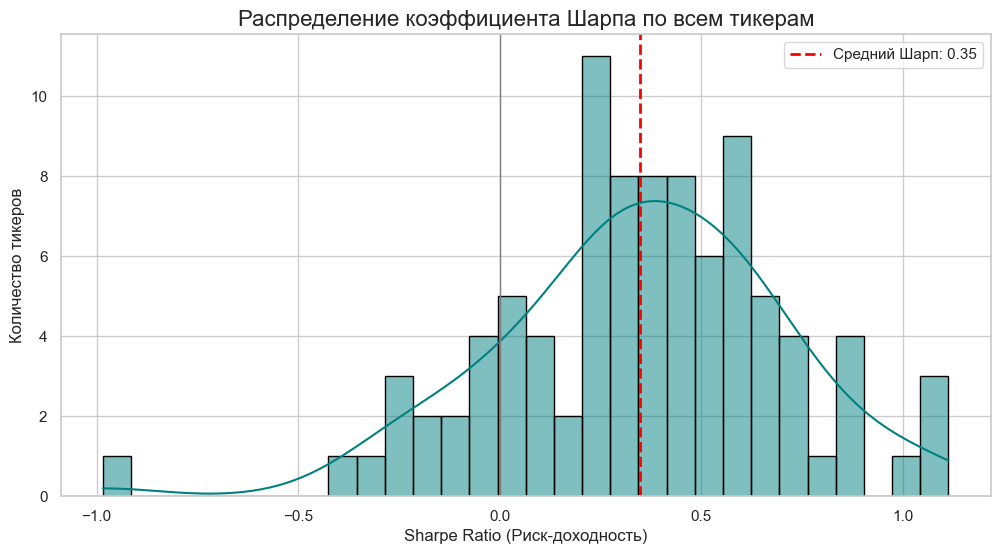

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Строим гистограмму с кривой плотности (KDE)
# dropna() нужен, чтобы убрать NaN (если у каких-то тикеров Шарп не посчитался)
sns.histplot(stats_df['Sharpe Ratio'].dropna(), bins=30, kde=True, color='teal', edgecolor='black')

# 2. Добавляем линию среднего значения
mean_sharpe = stats_df['Sharpe Ratio'].mean()
plt.axvline(mean_sharpe, color='red', linestyle='--', linewidth=2, label=f'Средний Шарп: {mean_sharpe:.2f}')

# 3. Добавляем линию нуля (граница убыточности)
plt.axvline(0, color='gray', linestyle='-', linewidth=1)

# Оформление
plt.title('Распределение коэффициента Шарпа по всем тикерам', fontsize=16)
plt.xlabel('Sharpe Ratio (Риск-доходность)', fontsize=12)
plt.ylabel('Количество тикеров', fontsize=12)
plt.legend()

plt.show()

In [30]:
# Лучший тикер
best_ticker = stats_df['Sharpe Ratio'].idxmax()

# Худший тикер (чтобы знать врага в лицо)
worst_ticker = stats_df['Sharpe Ratio'].idxmin()

# Рисуем графики
print(f"\nГрафик для ЛУЧШЕГО тикера: {best_ticker}")
pf[best_ticker].plot().show()

print(f"\nГрафик для ХУДШЕГО тикера: {worst_ticker}")
pf[worst_ticker].plot().show()


График для ЛУЧШЕГО тикера: (10, 50, 'AKRN')



График для ХУДШЕГО тикера: (10, 50, 'MAIL')


1. Лидеры 

Это акции с самым высоким коэффициентом Шарпа (то есть риск оправдан доходностью).

- Акрон (AKRN): Шарп 1.11, Доходность +17,613%. Это абсолютный чемпион. Экспортеры удобрений отлично трендятся.
- Татнефть-преф (TATNP): Шарп 1.06.
- Сбер-преф (SBERP): Шарп 1.04.
- АФК Система (AFKS): Шарп 0.98.

Стратегия хорошо работает на "дивидендных фишках" и экспортерах. Это логично: у них длинные циклы роста, связанные с ценами на сырье или восстановлением экономики, которые скользящие средние (MA 10/50) ловят великолепно.

2.  Аутсайдеры 
Где стратегия теряет деньги:

- VK (MAIL): Шарп -0.98.
- Fix Price (FIXP), UGLD, QIWI.
- Max Drawdown: У некоторых бумаг просадка достигает 80-90% (QIWI, возможно из-за делистинга/корпоративных событий).

 Стратегия плоха для IT-сектора и недавних IPO на падающем тренде. Скользящие средние там просто "пилят" депозит (много ложных входов).

3. Общая статистика ("Средняя по больнице")
Средний Шарп: 0.35. Это положительное значение, но не очень высокое. Хедж-фонды ищут Шарп > 1. Для простой стратегии 0.35 — это нормально, но требует диверсификации.

Win Rate (Процент побед): В среднем 37%. Это классика трендовых стратегий. Вы чаще теряете, чем зарабатываете (37% прибыльных сделок против 63% убыточных). Но за счет того, что прибыльные сделки (тренды) очень большие, вы в плюсе. Психологически это тяжело торговать.

In [84]:
# 1. Определяем, где данные существуют (не NaN и не 0)
# Это наша матрица "существования" актива
exists_mask = close_df.notnull() & (close_df > 0)

# 2. Генерируем сигнал входа (Entry)
# Логика: Нам нужна первая "единица" в каждом столбце.
# cumsum() накапливает True как 1.
# Там, где сумма равна 1, и находится первый день торгов.
entries_bh = (exists_mask.cumsum() == 1) & exists_mask

# 3. Сигнал выхода (Exit)
# Для Buy & Hold мы никогда не продаем (или продаем в самый последний день, если нужно закрыть позицию)
# Здесь ставим False - держим вечно.
exits_bh = pd.DataFrame(False, index=close_df.index, columns=close_df.columns)

# 4. Считаем портфель Buy & Hold
pf_bh = vbt.Portfolio.from_signals(
    close_df,
    entries_bh,
    exits_bh,
    init_cash=100,
    fees=0.001,  # Комиссию тоже учитываем, один раз на входе
    freq='1D'
)

print(f"Buy & Hold рассчитан для {len(close_df.columns)} тикеров с учетом их индивидуальных дат старта.")

Buy & Hold рассчитан для 100 тикеров с учетом их индивидуальных дат старта.


In [83]:
pf_bh.stats()

C:\Users\marce\AppData\Local\Temp\ipykernel_37468\1629393389.py:1: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x000002C7200BF1A0>. Pass column to select a single column/group.



Start                                  2001-12-07 00:00:00
End                                    2025-12-30 00:00:00
Period                                  6083 days 00:00:00
Start Value                                          100.0
End Value                                     14394.976413
Total Return [%]                              14294.976413
Benchmark Return [%]                          14008.350374
Max Gross Exposure [%]                                99.0
Total Fees Paid                                   0.098901
Max Drawdown [%]                                 82.955462
Max Drawdown Duration         1945 days 04:36:21.818181824
Total Trades                                          0.99
Total Closed Trades                                    0.0
Total Open Trades                                     0.99
Open Trade PnL                                14292.316948
Win Rate [%]                                           NaN
Best Trade [%]                                         N

# Реалистичная оценка (walk forward)

-   

In [85]:
# 1. Разделяем данные на "Прошлое" и "Имитацию будущего"
split_date = '2022-01-01'

# Тестовая выборка (OOS - Out of Sample)
test_df = close_df.loc[split_date:]

print(f"Тестируем стратегию на данных с {split_date} (Период кризисов и санкций)")
print(f"Количество торговых дней: {len(test_df)}")

# 2. Запускаем ТУ ЖЕ стратегию (SMA 10/50), но только на новых данных
# Считаем индикаторы только для куска test_df
fast_ma_test = vbt.MA.run(test_df, 10)
slow_ma_test = vbt.MA.run(test_df, 50)

entries_test = fast_ma_test.ma_crossed_above(slow_ma_test)
exits_test = fast_ma_test.ma_crossed_below(slow_ma_test)

# Очистка от NaN (на всякий случай)
valid_mask_test = test_df.notnull() & (test_df > 0)
entries_test = entries_test & valid_mask_test
exits_test = exits_test & valid_mask_test

# Портфель Стратегии (Test)
pf_test = vbt.Portfolio.from_signals(
    test_df, 
    entries_test, 
    exits_test, 
    init_cash=100, 
    fees=0.001, 
    freq='1D'
)

# 3. Запускаем Buy & Hold на том же периоде (Benchmark)
# Вход в первый доступный день 2022 года
entries_bh_test = (valid_mask_test.cumsum() == 1) & valid_mask_test
exits_bh_test = pd.DataFrame(False, index=test_df.index, columns=test_df.columns)

pf_bh_test = vbt.Portfolio.from_signals(
    test_df, 
    entries_bh_test, 
    exits_bh_test, 
    init_cash=100, 
    fees=0.001,
    freq='1D'
)

# 4. Сравниваем результаты в "Будущем"
res_test = pd.DataFrame({
    'Strategy (2022+)': pf_test.total_return() * 100,
    'Buy&Hold (2022+)': pf_bh_test.total_return() * 100
})

res_test['Alpha'] = res_test['Strategy (2022+)'] - res_test['Buy&Hold (2022+)']

print("\nРезультаты проверки боем (2022-2026):")
print(f"Средняя доходность стратегии: {res_test['Strategy (2022+)'].mean():.2f}%")
print(f"Средняя доходность рынка:     {res_test['Buy&Hold (2022+)'].mean():.2f}%")
print(f"Средняя Альфа:                {res_test['Alpha'].mean():.2f}%")

# Визуализация для всего портфеля
print("\nСравнение кривых капитала (накопленный итог):")
pf_test.plot_value().show()

Тестируем стратегию на данных с 2022-01-01 (Период кризисов и санкций)
Количество торговых дней: 1062

Результаты проверки боем (2022-2026):
Средняя доходность стратегии: 89.88%
Средняя доходность рынка:     42.15%
Средняя Альфа:                nan%

Сравнение кривых капитала (накопленный итог):


C:\Users\marce\AppData\Local\Temp\ipykernel_37468\1108965762.py:48: RuntimeWarning:

The values in the array are unorderable. Pass `sort=False` to suppress this warning.



TypeError: Only one column is allowed. Use indexing or column argument.